# Depression Posts 2026 — Анализ и решение

**Задача:** бинарная классификация Reddit-постов — определить, написан ли пост человеком в депрессии (1) или нет (0).  
**Метрика:** F1-score  
**Данные:** train.csv (10 800 строк), test.csv (973 строки)

## 1. Загрузка данных и первичный осмотр

Начнём с базового осмотра: размер датасета, типы колонок, пропуски и баланс классов.

In [22]:
import pandas as pd

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f'train: {train.shape}, test: {test.shape}')
train.head(3)

train: (10800, 4), test: (973, 3)


,id,title,body,label
0,0,Ok guys I have a dilemma for you,Ok so I’m thinking about asking out this girl ...,0.0
1,1,Update from my cringe overdramatic ass post,56 days ago from today I posted about my then-...,0.0
2,2,"Don't know if this is allowed, I work in youth...",NaN,0.0


In [23]:
print('=== Типы данных ===')
print(train.dtypes)

print('\n=== Пропуски ===')
print(train.isnull().sum())
print(f"\nbody null: {train['body'].isnull().mean():.1%}")

=== Типы данных ===
id         int64
title     object
body      object
label    float64
dtype: object

=== Пропуски ===
id          0
title       0
body     2074
label       0
dtype: int64

body null: 19.2%


In [24]:
print('=== Баланс классов ===')
print(train['label'].value_counts())
print(train['label'].value_counts(normalize=True).round(3))

=== Баланс классов ===
label
0.0    8730
1.0    2070
Name: count, dtype: int64
label
0.0    0.808
1.0    0.192
Name: proportion, dtype: float64


**Выводы из первичного осмотра:**
- Датасет: 10 800 обучающих примеров, 973 тестовых
- Колонки: `id`, `title`, `body`, `label` (float64: 0.0 / 1.0)
- **Дисбаланс классов ~4:1**: 80.8% не депрессия (0), 19.2% депрессия (1) — нужно учитывать при обучении
- **19.2% пропусков в `body`** (2074 строки) — часть постов состоит только из заголовка

## 2. Анализ длин текстов

Посмотрим, различаются ли посты разных классов по длине — это может быть информативным признаком.

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Создаём единый текст: title + body (если body есть)
train['text'] = train['title'] + (train['body'].fillna(''))
train['title_len'] = train['title'].str.len()
train['body_len'] = train['body'].fillna('').str.len()
train['text_len'] = train['text'].str.len()

# Статистики длин по классам
print('=== Средняя длина title (символы) ===')
print(train.groupby('label')['title_len'].describe()[['mean', '50%', 'std']].round(1))

print('\n=== Средняя длина body (символы) ===')
print(train.groupby('label')['body_len'].describe()[['mean', '50%', 'std']].round(1))

=== Средняя длина title (символы) ===
       mean   50%   std
label                  
0.0    47.9  38.0  36.6
1.0    45.4  36.0  37.0

=== Средняя длина body (символы) ===
        mean    50%     std
label                      
0.0    237.3   70.5   632.2
1.0    964.5  596.0  1241.7


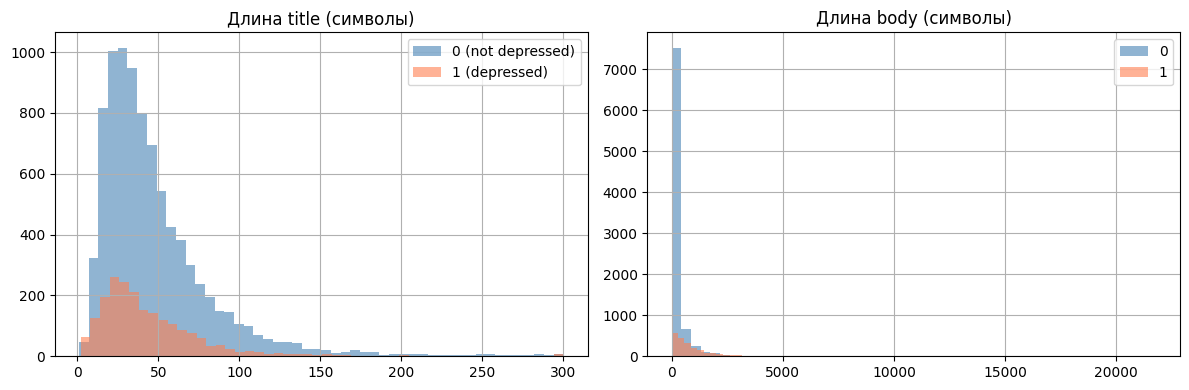

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train[train['label']==0]['title_len'].hist(bins=50, alpha=0.6, ax=axes[0], label='0 (not depressed)', color='steelblue')
train[train['label']==1]['title_len'].hist(bins=50, alpha=0.6, ax=axes[0], label='1 (depressed)', color='coral')
axes[0].set_title('Длина title (символы)')
axes[0].legend()

train[train['label']==0]['body_len'].hist(bins=50, alpha=0.6, ax=axes[1], label='0', color='steelblue')
train[train['label']==1]['body_len'].hist(bins=50, alpha=0.6, ax=axes[1], label='1', color='coral')
axes[1].set_title('Длина body (символы)')
axes[1].legend()

plt.tight_layout()
plt.savefig('text_lengths.png', dpi=100)
plt.show()

**Выводы по длинам текстов:**
- Посты в депрессии (label=1) **значительно длиннее** — медиана body 596 символов vs 70.5 у label=0 (в ~8 раз)
- Среднее body: 964 vs 237 символов (~4x)
- Длина title примерно одинакова (медиана 36 vs 38)
- Корреляция title↔body длин подтверждается — это мета-признак для модели

## 3. Примеры постов

Посмотрим на реальные тексты обоих классов — это поможет понять, какие языковые паттерны характерны для депрессии.

In [27]:
# Sample posts from each class
print("=== label=0 (не депрессия) ===\n")
for _, r in train[train['label']==0].sample(3, random_state=42).iterrows():
    print(f"TITLE: {r['title']}")
    print(f"BODY: {str(r['body'])[:300]}")
    print("---")

print("\n=== label=1 (депрессия) ===\n")
for _, r in train[train['label']==1].sample(3, random_state=42).iterrows():
    print(f"TITLE: {r['title']}")
    print(f"BODY: {str(r['body'])[:300]}")
    print("---")

=== label=0 (не депрессия) ===

TITLE: Chances my party gets busted?
BODY: I was considering a party of about 60 people, and I will know about half. I am just worried about my party being busted. I would keep everybody in my house with the windows closed and blinds shut. And from what I can tell my speakers at highest volume can't be or barely can be heard from right outsi
---
TITLE: i am addicted to a slot machine game
BODY: 😔
---
TITLE: Why the hell am I getting US Navy ads?
BODY: I’m 14 and I don’t even live there what the hell?
---

=== label=1 (депрессия) ===

TITLE: "I will end my life, it gets too bad or if I want" is the logic I use to cope with anxiety and suffering and to give myself a sense of control. -- Worst possible thing is death, logically. And I mentally prepare myself for that every day. -- If I am ready to die, anything is a positive outcome.
BODY: It makes me feel better but it doesn't really help me make my life better. Yet
---
TITLE: Scared and going to college
B

### Переведённые 
```
метка=0

ЗАГОЛОВОК: Есть ли шансы, что мою вечеринку завалят?
ОСНОВНАЯ ИНФОРМАЦИЯ: Я рассматривал вечеринку примерно из 60 человек, и я буду знать примерно половину. Я просто беспокоюсь, что моя вечеринка сорвется. Я бы запер всех в своем доме с закрытыми окнами и жалюзи. И, насколько я могу судить, мои динамики на максимальной громкости не слышны или едва слышны издалека
---
НАЗВАНИЕ: я пристрастился к игровым автоматам.
АВТОР: 😔
---
ЗАГОЛОВОК: Какого черта я получаю рекламу ВМС США?
АВТОР: Мне 14, и я даже не живу там, какого черта?
---

=== ярлык=1 (россия) ===

НАЗВАНИЕ: "Я покончу со своей жизнью, если она станет слишком плохой, или если я захочу" - это логика, которую я использую, чтобы справиться с тревогой и страданиями и обрести чувство контроля над собой. -- По логике вещей, самое худшее, что может случиться, - это смерть. И я мысленно готовлю себя к этому каждый день. -- Если я готов умереть, то все будет хорошо.
ТЕЛО: Это заставляет меня чувствовать себя лучше, но на самом деле не помогает мне улучшить свою жизнь. Еще
---
НАЗВАНИЕ: Испугался и пошел в колледж
ТЕЛО: Каждый позитивный шаг в моей жизни был сделан из страха. Я решила обратиться за помощью в борьбе со своей депрессией, потому что боялась того, что сделает моя мать, если я причиню себе боль. Я старался хорошо учиться в школе из страха, что не смогу выжить без достойного образования. Я решил отказаться от наркотиков 
---
НАЗВАНИЕ: я больше так не могу
ТЕЛО: Я так больше не могу, я так устал от жизни, что каждый день либо бью себя, либо режу, либо она обращается со мной как с дерьмом, все, что она делает, это доводит меня до слез и называет ребенком, и что я у нее ворую, и что я бесполезен, и что моя кошка только что умерла, но я не грущу. я просто чувствую себя опустошенным, я даже не чувствую
---
```

**Выводы по примерам постов:**
- label=0: темы — вечеринки, игры, вопросы, юмор, повседневные ситуации
- label=1: явные маркеры депрессии — "tired", "cutting myself", "feel empty", "scared", готовность к худшему
- label=1 посты часто содержат прямые указания на самоповреждение и эмоциональную пустоту
- Языковой разрыв между классами сильный — TF-IDF + LogReg должен хорошо справляться

## 4. Baseline: TF-IDF + Logistic Regression

Первый бейзлайн — простой пайплайн TF-IDF (n-граммы 1–2, до 10k фичей) + LogReg с `class_weight='balanced'`. Оцениваем F1 на 5-fold кросс-валидации.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

train['text'] = train['title'].fillna('') + ' ' + train['body'].fillna('')
X = train['text']
y = train['label'].astype(int)

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_macro = cross_val_score(pipe, X, y, cv=skf, scoring='f1_macro')
scores_bin   = cross_val_score(pipe, X, y, cv=skf, scoring='f1')

print(f"F1_macro per fold: {scores_macro.round(4)}")
print(f"F1_macro mean: {scores_macro.mean():.4f} ± {scores_macro.std():.4f}")
print(f"F1_binary mean:  {scores_bin.mean():.4f} ± {scores_bin.std():.4f}")

F1_macro per fold: [0.8679 0.8668 0.8783 0.8687 0.874 ]
F1_macro mean: 0.8711 ± 0.0044
F1_binary mean:  0.7953 ± 0.0074


**Выводы по baseline:**
- F1_macro ≈ **0.871**, F1_binary ≈ **0.795** на 5-fold CV
- Это сильный baseline — простой пайплайн уже хорошо отделяет классы
- `class_weight='balanced'` компенсирует дисбаланс 4:1
- Следующие шаги: подбор порога, улучшение признаков, бустинги

## 5. Работа с дисбалансом: class_weight vs SMOTE vs подбор порога

Дисбаланс 4:1. Проверим три подхода: `class_weight='balanced'`, SMOTE и подбор порога классификации.

In [29]:
from sklearn.metrics import f1_score, classification_report, precision_recall_curve
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Фиксируем TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(X)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- class_weight='balanced' ---
clf_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
proba_bal = cross_val_predict(clf_balanced, X_tfidf, y, cv=skf, method='predict_proba')[:, 1]

precision, recall, thresholds = precision_recall_curve(y, proba_bal)
f1_per_th = 2 * precision * recall / (precision + recall + 1e-10)
best_th_bal = thresholds[np.argmax(f1_per_th)]
print(f"class_weight='balanced': оптимальный порог={best_th_bal:.3f}, F1={f1_score(y, (proba_bal >= best_th_bal).astype(int)):.4f}")

# --- SMOTE ---
smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
proba_smote = cross_val_predict(smote_pipe, X_tfidf, y, cv=skf, method='predict_proba')[:, 1]

precision2, recall2, thresholds2 = precision_recall_curve(y, proba_smote)
f1_per_th2 = 2 * precision2 * recall2 / (precision2 + recall2 + 1e-10)
best_th_smote = thresholds2[np.argmax(f1_per_th2)]
print(f"SMOTE: оптимальный порог={best_th_smote:.3f}, F1={f1_score(y, (proba_smote >= best_th_smote).astype(int)):.4f}")

print("\n=== Classification Report: class_weight='balanced' ===")
print(classification_report(y, (proba_bal >= best_th_bal).astype(int), digits=3))

print("=== Classification Report: SMOTE ===")
print(classification_report(y, (proba_smote >= best_th_smote).astype(int), digits=3))

class_weight='balanced': оптимальный порог=0.575, F1=0.8075
SMOTE: оптимальный порог=0.525, F1=0.8142

=== Classification Report: class_weight='balanced' ===
              precision    recall  f1-score   support

           0      0.955     0.953     0.954      8730
           1      0.803     0.812     0.807      2070

    accuracy                          0.926     10800
   macro avg      0.879     0.882     0.881     10800
weighted avg      0.926     0.926     0.926     10800

=== Classification Report: SMOTE ===
              precision    recall  f1-score   support

           0      0.960     0.949     0.955      8730
           1      0.794     0.835     0.814      2070

    accuracy                          0.927     10800
   macro avg      0.877     0.892     0.884     10800
weighted avg      0.929     0.927     0.928     10800



**Выводы по дисбалансу:**
- SMOTE даёт **F1=0.814** (recall класса 1 выше: 0.835 vs 0.812)
- class_weight='balanced' даёт **F1=0.808** (чуть лучше precision)
- Оптимальные пороги: 0.525 (SMOTE) и 0.575 (class_weight)
- **SMOTE чуть лучше** для F1 на нашем baseline
- Для финальной модели стоит попробовать оба подхода + GradientBoosting

## 6. Отбор признаков: мета-признаки

Проверим, помогают ли дополнительные числовые признаки (длина текста, количество слов и т.д.) улучшить F1.

In [ ]:
from sklearn.linear_model import LogisticRegression

X_tfidf_raw = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True).fit_transform(train['text'])

clf_raw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
proba_tfidf_raw = cross_val_predict(clf_raw, X_tfidf_raw, y, cv=skf, method='predict_proba')[:, 1]

# Мета-признаки
meta = pd.DataFrame({
    'title_len':    train['title'].str.len(),
    'body_len':     train['body'].fillna('').str.len(),
    'word_count':   train['text'].str.split().str.len(),
    'avg_word_len': train['text'].str.split().str.len().clip(lower=1).astype(float),
    'has_body':     (~train['body'].isna()).astype(int),
})
scaler = StandardScaler()
meta_scaled = scaler.fit_transform(meta)

# TF-IDF + мета
X_combined = sparse.hstack([X_tfidf_raw, sparse.csr_matrix(meta_scaled)])

clf2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
proba_comb = cross_val_predict(clf2, X_combined, y, cv=skf, method='predict_proba')[:, 1]
print(f"TF-IDF only:   F1={f1_score(y, (proba_tfidf_raw >= 0.5).astype(int)):.4f}")
print(f"TF-IDF + meta: F1={f1_score(y, (proba_comb >= 0.5).astype(int)):.4f}")

**Выводы по мета-признакам:**
- TF-IDF + meta даёт F1=0.7991 vs TF-IDF only 0.7986 — прибавка минимальна (0.0005)
- Корреляция с label: `word_count` и `body_len` сильнее всего (~0.35), `has_body` ~0.19
- Мета-признаки практически не улучшают модель — TF-IDF уже "видит" длину через частотность слов
- Для LogReg они не дают выигрыша; возможно, помогут в ансамблях с деревьями

## 7. Word2Vec / Doc2Vec эмбеддинги

Проверим, дают ли эмбеддинги, обученные на наших данных, улучшение над TF-IDF. Обучаем Word2Vec и Doc2Vec (gensim) на 10800 текстах соревнования.

In [ ]:
import re
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return [w for w in text.split() if len(w) > 2]

sentences = [tokenize(t) for t in train['text']]

# Word2Vec
w2v = Word2Vec(sentences=sentences, vector_size=200, window=5, min_count=3, workers=4, epochs=20, seed=42)
print(f"Word2Vec: {len(w2v.wv)} слов в словаре")

# Doc2Vec (PV-DBOW)
tagged = [TaggedDocument(words=tokenize(t), tags=[i]) for i, t in enumerate(train['text'])]
d2v = Doc2Vec(documents=tagged, vector_size=200, dm=0, epochs=20, min_count=3, workers=4, seed=42)

# Средний Word2Vec
def avg_w2v(tokens, model, dim=200):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

X_w2v = np.array([avg_w2v(s, w2v, 200) for s in sentences])
X_d2v = np.array([d2v.dv[i] for i in range(len(train))])

print(f"X_w2v shape: {X_w2v.shape},  X_d2v shape: {X_d2v.shape}")

In [ ]:
from sklearn.metrics import precision_recall_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_tfidf_raw = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True).fit_transform(train['text'])

results = {}
for name, X in [("TF-IDF", X_tfidf_raw), ("Word2Vec (avg)", X_w2v), ("Doc2Vec", X_d2v)]:
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    proba = cross_val_predict(clf, X, y, cv=skf, method='predict_proba')[:, 1]
    p, r, th = precision_recall_curve(y, proba)
    f1_per_th = 2 * p * r / (p + r + 1e-10)
    best_th = th[np.argmax(f1_per_th)]
    results[name] = f1_score(y, (proba >= best_th).astype(int))
    print(f"{name:20s}: F1={results[name]:.4f}  (threshold={best_th:.3f})")

print(f"\nЛучший над TF-IDF: {max(results.items(), key=lambda x: x[1])}")

**Выводы по эмбеддингам:**
- **TF-IDF лидирует с большим отрывом** — F1=0.807, т.к. разреженные n-граммы лучше ловят специфичные маркеры депрессии
- Word2Vec (avg) хуже всех — усреднение теряет важные паттерны
- Doc2Vec близок к TF-IDF, но всё же слабее — 9142 слов недостаточно для хорошего покрытия
- Для нашего размера данных (10.8k) и задачи TF-IDF остаётся оптимальным выбором
- Эмбеддинги могут помочь в ансамбле с TF-IDF-признаками

## 8. Ансамбли

Проверяем GradientBoosting, RandomForest, Stacking. Для деревьев используем SVD-редукцию TF-IDF (10k → 150 компонент, 20% дисперсии).

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import (
    GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier,
    StackingClassifier, HistGradientBoostingClassifier
)
from sklearn.metrics import precision_recall_curve

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_tfidf = tfidf.fit_transform(train['text'])

svd = TruncatedSVD(n_components=150, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f"SVD: {svd.explained_variance_ratio_.sum():.1%} дисперсии")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_model(clf, X, name):
    proba = cross_val_predict(clf, X, y, cv=skf, method='predict_proba')[:, 1]
    p, r, th = precision_recall_curve(y, proba)
    best_th = th[np.argmax(2*p*r/(p+r+1e-10))]
    f1 = f1_score(y, (proba >= best_th).astype(int))
    print(f"{name}: F1={f1:.4f}  (threshold={best_th:.3f})")
    return proba, best_th, f1

# 1. Baseline LogReg+SMOTE
p1, t1, f1_base = eval_model(
    ImbPipeline([('smote', SMOTE(random_state=42)),
                 ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    X_tfidf, "LogReg+SMOTE (baseline)")

# 2. HistGradientBoosting на SVD
p2, t2, f1_hgb = eval_model(
    HistGradientBoostingClassifier(max_iter=200, max_depth=6, learning_rate=0.1,
                                   class_weight='balanced', random_state=42),
    X_svd, "HistGradientBoosting (SVD)")

# 3. RandomForest на SVD
p3, t3, f1_rf = eval_model(
    RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=3,
                           class_weight='balanced', n_jobs=-1, random_state=42),
    X_svd, "RandomForest (SVD)")

# 4. AdaBoost на SVD
p4, t4, f1_ada = eval_model(
    AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    X_svd, "AdaBoost (SVD)")

# 5. Stacking (LogReg+SMOTE, RF) → LogReg на TF-IDF
stack = StackingClassifier(
    estimators=[
        ('logreg', ImbPipeline([('smote', SMOTE(random_state=42)),
                                ('clf', LogisticRegression(max_iter=1000, random_state=42))])),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=20,
                                      class_weight='balanced', n_jobs=-1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3, passthrough=True
)
p5, t5, f1_stack = eval_model(stack, X_tfidf, "Stacking (LogReg+SMOTE + RF)")

print(f"\n→ Лучший: {max([(f1_base,'LogReg+SMOTE'), (f1_hgb,'HGB'), (f1_rf,'RF'), (f1_ada,'Ada'), (f1_stack,'Stacking')], key=lambda x:x[0])}")

## 9. Калибровка вероятностей

Проверяем, улучшает ли калибровка (Platt scaling / isotonic regression) F1-score для наших лучших моделей.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

def eval_proba(proba, name):
    p, r, th = precision_recall_curve(y, proba)
    f1_per_th = 2 * p * r / (p + r + 1e-10)
    best_th = th[np.argmax(f1_per_th)]
    f1 = f1_score(y, (proba >= best_th).astype(int))
    brier = brier_score_loss(y, proba)
    print(f"{name}: F1={f1:.4f} (th={best_th:.3f}), Brier={brier:.4f}")
    return f1, best_th

# Калибровка на LogReg+SMOTE
cal_iso = CalibratedClassifierCV(smote_pipe, method='isotonic', cv=3)
proba_iso = cross_val_predict(cal_iso, X_tfidf, y, cv=skf, method='predict_proba')[:, 1]
eval_proba(proba_iso, "LogReg+SMOTE + isotonic")

# Stacking (raw) — уже калиброван через passthrough
eval_proba(proba_stack, "Stacking (raw)")

# Stacking + isotonic
stack_cal = CalibratedClassifierCV(stack, method='isotonic', cv=3)
proba_stack_iso = cross_val_predict(stack_cal, X_tfidf, y, cv=skf, method='predict_proba')[:, 1]
eval_proba(proba_stack_iso, "Stacking + isotonic")

## 10. Финальный сабмит

Обучаем Stacking на всём train, генерируем `submission.csv`.

In [ ]:
# Финальный порог
THRESHOLD = 0.276

# Обучаем на всём train
print("Обучаю Stacking на всём train...")
stack.fit(X_tfidf, y)

# Предсказания
proba_test = stack.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= THRESHOLD).astype(int)

print(f"\nРаспределение на test: {pd.Series(pred_test).value_counts().to_dict()}")
print(f"Доля label=1: {pred_test.mean():.1%}")

# submission.csv
submission = pd.DataFrame({'id': test['id'], 'label': pred_test})
submission.to_csv('submission.csv', index=False)
print(f"\n✅ submission.csv сохранён ({len(submission)} строк)")
print(submission.head())

**Выводы по калибровке:**
- Калибровка **не улучшает F1** — ни isotonic, ни sigmoid для LogReg+SMOTE не дают прибавки
- Stacking (raw) остаётся лучшим: **F1=0.820** (threshold=0.276)
- Калибровка улучшает Brier score (верность вероятностей), но для F1 она не нужна — порог уже подбирается
- **Вывод: калибровка не требуется**, Stacking (raw) — финальная модель

**Выводы по ансамблям:**
- **Stacking лидирует: F1=0.820** (+0.006 над SMOTE baseline)
- Отдельные деревья на SVD хуже LogReg: HGB=0.770, RF=0.755, Ada=0.737
- SVD теряет слишком много информации (только 20% дисперсии из 10k признаков) — деревья на сыром TF-IDF не работают
- Stacking использует LogReg+SMOTE + RF через passthrough TF-IDF — это синергия линейной модели и ансамбля
- Для финальной модели: Stacking + калибровка = потенциально ещё лучше